**Task 5: Content Rating & Genre Analysis**

In [1]:
import pandas as pd

In [2]:
#Load dataset
df=pd.read_csv(r"netflix_cleaned.csv")
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [3]:
#Step 1 — Analyze Rating Categories

# Check the rating values
df['rating'].unique()

array(['PG-13', 'TV-MA', 'TV-PG', 'TV-14', 'TV-Y7', 'TV-Y', 'PG', 'TV-G',
       'R', 'G', 'NC-17', 'NR', 'TV-Y7-FV', 'UR'], dtype=object)

In [4]:
#Count each rating
rating_counts = df['rating'].value_counts()
print(rating_counts)

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64


In [5]:
#Check the percentage distribution
rating_percentage = df['rating'].value_counts(normalize=True) * 100
print(rating_percentage.round(2))

rating
TV-MA       36.46
TV-14       24.54
TV-PG        9.80
R            9.09
PG-13        5.57
TV-Y7        3.79
TV-Y         3.48
PG           3.27
TV-G         2.50
NR           0.90
G            0.47
TV-Y7-FV     0.07
NC-17        0.03
UR           0.03
Name: proportion, dtype: float64


In [6]:
#Create a summary table
rating_summary = pd.DataFrame({'rating_count': rating_counts,
    'percentage': rating_percentage.round(2)})

(rating_summary)

,rating_count,percentage
rating,,
TV-MA,3205,36.46
TV-14,2157,24.54
TV-PG,861,9.80
R,799,9.09
PG-13,490,5.57
TV-Y7,333,3.79
TV-Y,306,3.48
PG,287,3.27
TV-G,220,2.50


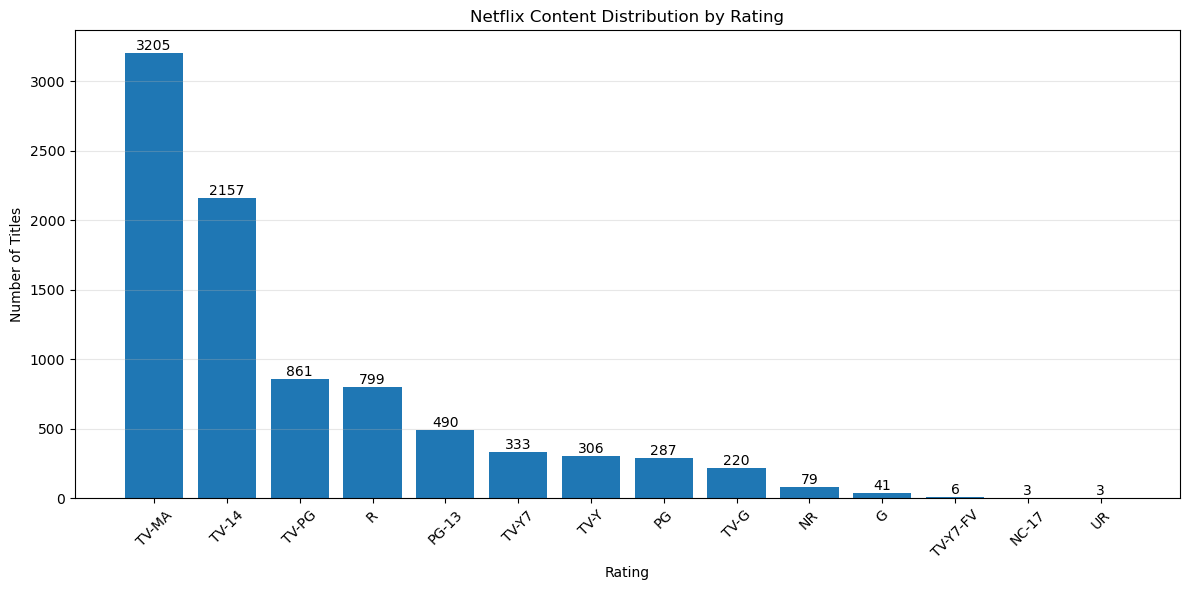

In [7]:
#Bar chart for rating analysis

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
bars = plt.bar(rating_counts.index,rating_counts.values)
plt.title('Netflix Content Distribution by Rating')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2,bar.get_height(),
        str(int(bar.get_height())),ha='center',va='bottom')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Step 1: Rating Analysis — Key Findings

- **TV-MA** is the most common rating, with **3,205 titles (36.46%)**.
- **TV-14** is the second most common rating, with **2,157 titles (24.54%)**.
- **TV-PG** accounts for **861 titles (9.80%)**, while **R** accounts for **799 titles (9.09%)**.
- TV-MA and TV-14 together represent **61% of the titles** in the dataset.
- The rating distribution indicates a strong presence of content targeted toward **teen and mature audiences**.

> **Note:** These findings describe the distribution of ratings in this Netflix dataset and should not be interpreted as Netflix's complete current catalog.

In [8]:
#Step 2 — Identify the Most Common Genres
df['listed_in'].head(10)

0                                        Documentaries
1    Crime TV Shows, International TV Shows, TV Act...
2                   TV Dramas, TV Horror, TV Mysteries
3                   Children & Family Movies, Comedies
4     Dramas, Independent Movies, International Movies
5                         British TV Shows, Reality TV
6                                     Comedies, Dramas
7    Children & Family Movies, Comedies, Music & Mu...
8                         Dramas, International Movies
9           Children & Family Movies, Music & Musicals
Name: listed_in, dtype: object

In [9]:
# Split multiple genres in each row
genres = df['listed_in'].str.split(', ')

In [10]:
# Put each genre on a separate row
genres = genres.explode()
print(genres.head(10))

0               Documentaries
1              Crime TV Shows
1      International TV Shows
1       TV Action & Adventure
2                   TV Dramas
2                   TV Horror
2                TV Mysteries
3    Children & Family Movies
3                    Comedies
4                      Dramas
Name: listed_in, dtype: object


In [11]:
#Count the genres
genre_counts = genres.value_counts()
print(genre_counts)

listed_in
International Movies            2752
Dramas                          2426
Comedies                        1674
International TV Shows          1349
Documentaries                    869
Action & Adventure               859
TV Dramas                        762
Independent Movies               756
Children & Family Movies         641
Romantic Movies                  616
Thrillers                        577
TV Comedies                      573
Crime TV Shows                   469
Kids' TV                         448
Docuseries                       394
Music & Musicals                 375
Romantic TV Shows                370
Horror Movies                    357
Stand-Up Comedy                  343
Reality TV                       255
British TV Shows                 252
Sci-Fi & Fantasy                 243
Sports Movies                    219
Anime Series                     174
Spanish-Language TV Shows        173
TV Action & Adventure            167
Korean TV Shows             

In [12]:
# Get top 10 genres
top_genres = genre_counts.head(10)
print(top_genres)

listed_in
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


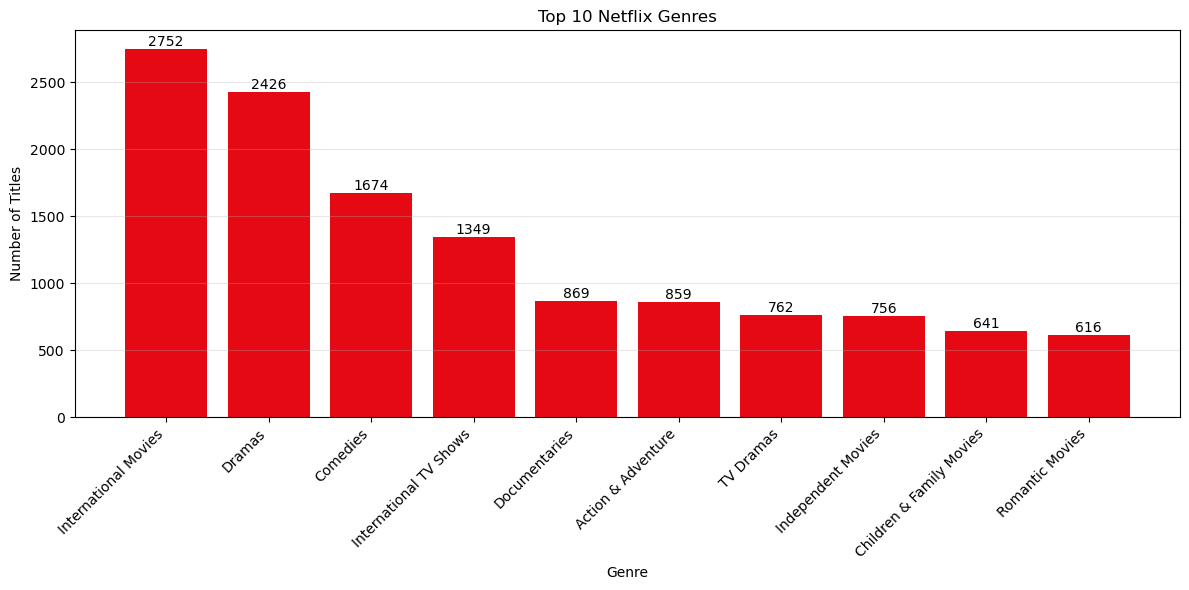

In [13]:
#Visualization

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
bars = plt.bar(top_genres.index,top_genres.values,color='#E50914')
plt.title('Top 10 Netflix Genres')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')

# Add values on top of bars
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2,bar.get_height(),
        str(int(bar.get_height())),ha='center',va='bottom')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Step 2: Genre Analysis — Key Findings

- **International Movies** is the most common genre/category, with **2,752 titles**.
- **Dramas** are the second most common, with **2,426 titles**.
- **Comedies** rank third, with **1,674 titles**.
- **International TV Shows** account for **1,349 genre associations**.
- Documentaries, Action & Adventure, TV Dramas, Independent Movies, Children & Family Movies, and Romantic Movies also appear among the top 10 categories.
- Overall, the dataset shows a strong presence of **international, drama, and comedy content**.

> **Note:** A single title can belong to multiple genres, so these values represent genre associations rather than unique titles.

In [14]:
#Step 3 — Compare Ratings Across Movies vs TV Shows

#Create a rating comparison table
rating_by_type = pd.crosstab(df['rating'],df['type'])
(rating_by_type)

type,Movie,TV Show
rating,,
G,41,0
NC-17,3,0
NR,75,4
PG,287,0
PG-13,490,0
R,797,2
TV-14,1427,730
TV-G,126,94
TV-MA,2062,1143


In [15]:
#Calculate percentages
rating_by_type_percentage = pd.crosstab(df['rating'],df['type'],
                    normalize='columns') * 100
(rating_by_type_percentage.round(2))

type,Movie,TV Show
rating,,
G,0.67,0.00
NC-17,0.05,0.00
NR,1.22,0.15
PG,4.68,0.00
PG-13,8.00,0.00
R,13.01,0.08
TV-14,23.29,27.40
TV-G,2.06,3.53
TV-MA,33.66,42.91


In [16]:
#Find the most common rating for each type
movie_ratings = df[df['type'] == 'Movie']['rating'].value_counts()

tv_ratings = df[df['type'] == 'TV Show']['rating'].value_counts()

print("Most common Movie rating:")
print(movie_ratings.head(1))
print("Most common TV Show rating:")
print(tv_ratings.head(1))

Most common Movie rating:
rating
TV-MA    2062
Name: count, dtype: int64
Most common TV Show rating:
rating
TV-MA    1143
Name: count, dtype: int64


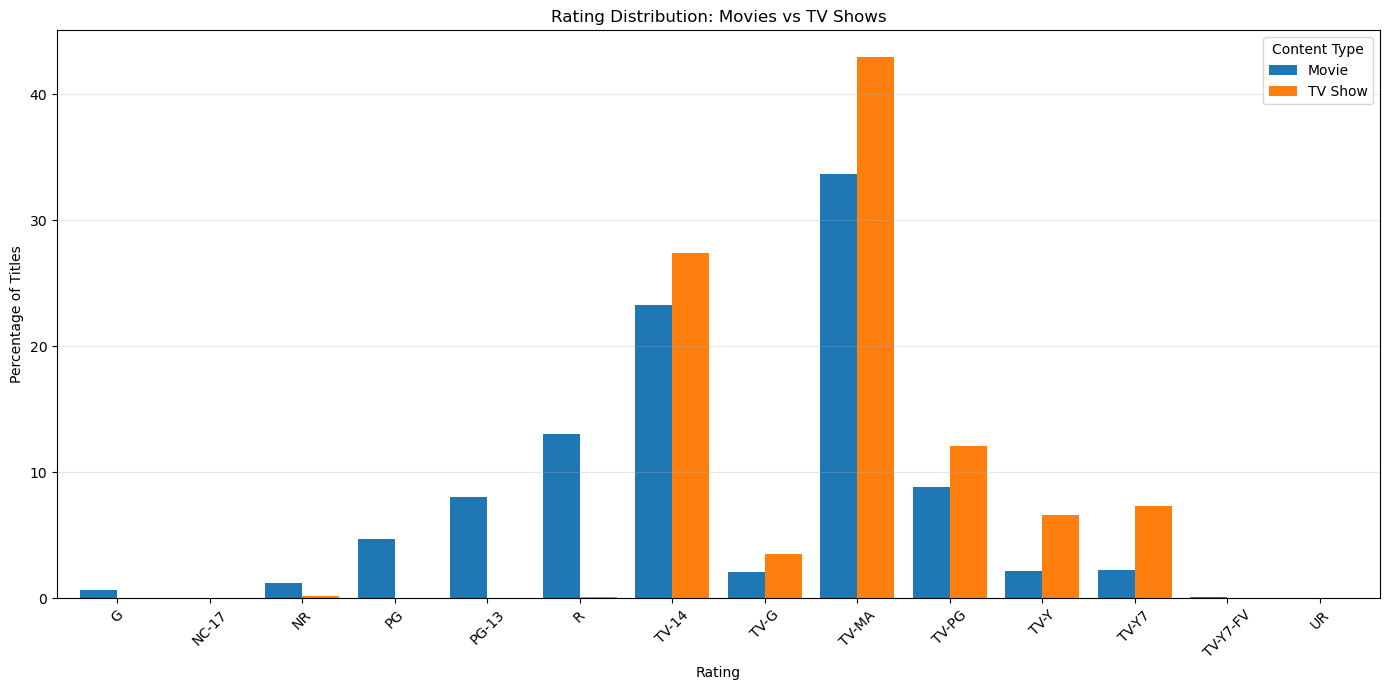

In [17]:
#Visualization

import matplotlib.pyplot as plt
# Create percentage table
rating_by_type_percentage = pd.crosstab(df['rating'],df['type'],
    normalize='columns') * 100

# Plot
ax = rating_by_type_percentage.plot(kind='bar',figsize=(14, 7),width=0.8)
plt.title('Rating Distribution: Movies vs TV Shows')
plt.xlabel('Rating')
plt.ylabel('Percentage of Titles')
plt.xticks(rotation=45)
plt.legend(title='Content Type')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Step 3: Rating Comparison — Movies vs TV Shows

- **TV-MA** is the most common rating for both Movies and TV Shows.
- TV-MA represents **33.66% of Movies** and **42.91% of TV Shows**.
- **TV-14** is the second major rating category, representing **23.29% of Movies** and **27.40% of TV Shows**.
- TV-MA and TV-14 together account for **56.95% of Movies** and **70.31% of TV Shows**.
- Movies have a notable share of ratings such as **R, PG-13, and PG**, reflecting the movie-specific rating system.
- TV Shows have a higher proportion of younger-audience categories such as **TV-Y, TV-Y7, and TV-PG**.

## Step 4: Audience Insights

The combined analysis of ratings, genres, and content types reveals several audience-targeting patterns in the Netflix dataset:

- The catalog has a strong concentration of content rated **TV-MA and TV-14**, indicating substantial representation of content targeted toward **teen and mature audiences**.
- **TV-MA** is the most common rating for both Movies and TV Shows, with a higher percentage among TV Shows.
- **International Movies** is the most common genre/category, followed by **Dramas** and **Comedies**, highlighting the strong presence of international and diverse content.
- The catalog also contains content aimed at **children and families**, including TV-Y, TV-Y7, TV-G, and Children & Family Movies.
- Movies and TV Shows show different rating distributions, reflecting their different rating systems and audience segments.

### Overall Conclusion

The Netflix dataset represents a diverse content catalog that targets multiple audience segments. However, **teen and mature audiences form a particularly large portion of the catalog**, while international, drama, and comedy content are among the most prominent genres.